In [1]:
# Copyright 2023 Nico Curti, Gianluca Carlini, and Riccardo Biondi
# Author: Nico Curti
# e-mail: nico.curti2@unibo.it

In [2]:
import numpy as np
import pylab as plt
import SimpleITK as sitk
from skimage.measure import marching_cubes
from graphomics import SkeletonizeImageFilter
from graphomics import GraphThicknessImageFilter

# Geometrical shapes

Demo of the `GraphThicknessImageFilter` applied to standard geometrical shapes.

This demo provides some naive examples about the skeletonization and following network extraction useful for a better understading of the filter.

As skeletonization algorithm we will use the Lee et al. implementation provided by `scikit-image` package and wrapped into the `SkeletonizeImageFilter` class.
The results show below can vary according to skeletonization algorithm chosen.
We would recommend to take a look at the ITK thickness algorithm for a better description of the possible approaches (ref. [here](https://github.com/InsightSoftwareConsortium/ITKThickness3D))

In [3]:
# define the skeletonizer to use in the following examples
skeletonizer = SkeletonizeImageFilter()

# define the graph extractor to use in the following examples
extractor = GraphThicknessImageFilter()

### Sphere

In [4]:
def sphere (shape: tuple, radius: int, position: tuple):
    '''
    Generate an n-dimensional spherical mask.
    '''
    # assume shape and position have the same length and contain ints
    # the units are pixels / voxels (px for short)
    # radius is a int or float in px
    assert len(position) == len(shape)
    n = len(shape)
    semisizes = (radius,) * len(shape)

    # genereate the grid for the support points
    # centered at the position indicated by position
    grid = [slice(-x0, dim - x0) for x0, dim in zip(position, shape)]
    position = np.ogrid[grid]
    # calculate the distance of all points from `position` center
    # scaled by the radius
    arr = np.zeros(shape, dtype=float)
    for x_i, semisize in zip(position, semisizes):
        # this can be generalized for exponent != 2
        # in which case `(x_i / semisize)`
        # would become `np.abs(x_i / semisize)`
        arr += (x_i / semisize) ** 2

    # the inner part of the sphere will have distance below or equal to 1
    return arr <= 1.0

No nodes found in the Graph


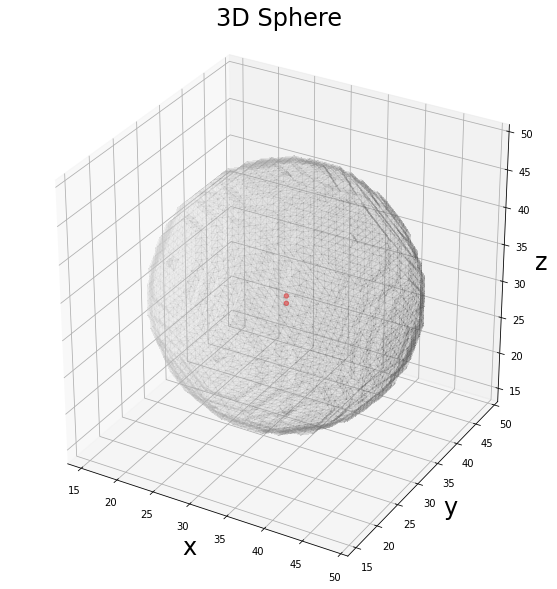

In [5]:
# create a 3D sphere as volume mask
volume = sphere(shape=(64, 64, 64), radius=16, position=(32, 32, 32))
sitk_volume = sitk.GetImageFromArray(np.uint8(volume))

# get the 3D skeleton of the object
skeletonizer.Execute(sitk_volume)
skeleton = skeletonizer.GetSkeletonImage()

# execute the filter
extractor.Execute(skeleton)

# get the returning values
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()
edgeLUT = extractor.GetEdgeLUTIndexes()
edges_lbl = extractor.GetEdgeMap()

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(volume)

# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
sz, sy, sx = np.where(sitk.GetArrayViewFromImage(skeleton))
if len(sx):
    ax.scatter(sx, sy, sz, color='r', marker='o', s=20, alpha=0.5)
else:
    print('No skeleton found')

# plot the nodes as blue dots
if len(nodes):
    ax.scatter(*zip(*nodes), color='b', marker='o', s=50)
else:
    print('No nodes found in the Graph')
    
# plot the edges as lines between vertices
for ex, ey in edges:
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=2)
    
# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.1,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Sphere', fontsize=24)

As expected, for a 3D sphere the number of points belonging to the skeleton is not sufficient for the identification of a network, since the skeleton is given by the center of the sphere.
The application of the filter is useless in this case.

**NOTE:** Despite the mathematical solution of the skeleton for the 3D sphere should provide only the center of the sphere, i.e. 1 point, the Lee skeletonization returns a couple of points!
This behaviour is due to the structural element used for the definition of the sphere.
Considering a sphere of radius 1 we can describe it as a cross element, a single voxel or a 2x2x2 cube.
All these definitions are correct and lead to different definition of the center of the sphere as belonging to a "real" voxel or to an "half" voxel.
According to the different definitions we can obtained different results as skeleton.

### Cylinder

In [6]:
def cylinder (shape: tuple, height: int, radius: int, position: tuple):
    '''
    Generate an n-dimensional cylindral mask.
    '''
    arr = np.zeros(shape, dtype=bool)
    x, y, z = shape
    x0, y0 = position
    
    # xx and yy are XY tables containing the x and y coordinates as values
    # mgrid is a mesh creation helper
    xx, yy = np.mgrid[:x, :y]
    # circles contains the squared distance to the central point
    # we are just using the circle equation learnt at school
    circle = (xx - x0) ** 2 + (yy - y0) ** 2

    circle = circle < radius**2
    start = z//2 - height//2
    stop  = start + height # i.e z//2 + height//2
    
    for i in range(start, stop):
        arr[..., i] = circle

    return arr

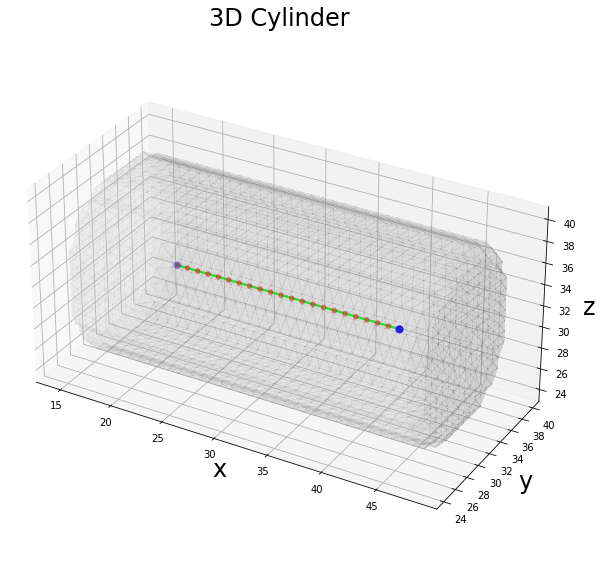

In [7]:
# create a 3D cylinder as volume mask
volume = cylinder(shape=(64, 64, 64), height=32, radius=8, position=(32, 32))
sitk_volume = sitk.GetImageFromArray(np.uint8(volume))

# get the 3D skeleton of the object
skeletonizer.Execute(sitk_volume)
skeleton = skeletonizer.GetSkeletonImage()

# execute the filter
extractor.Execute(skeleton)

# get the returning values
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()
edgeLUT = extractor.GetEdgeLUTIndexes()
edges_lbl = extractor.GetEdgeMap()

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(volume, 0)

# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
sz, sy, sx = np.where(sitk.GetArrayViewFromImage(skeleton))
if len(sx):
    ax.scatter(sx, sy, sz, color='r', marker='o', s=20, alpha=0.5)
else:
    print('No skeleton found')

# plot the nodes as blue dots
if len(nodes):
    ax.scatter(*zip(*nodes), color='b', marker='o', s=50)
else:
    print('No nodes found in the Graph')
    
# plot the edges as lines between vertices
for ex, ey in edges:
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=2)
    
# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.1,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Cylinder', fontsize=24)

The skeleton of a 3D cylinder is given by the central axis along the major dimension of the volume.
Since the skeleton is given by just a segment, the corresponding graph will have 2 nodes (the extreme points of the segment) and 1 link (the segment which connect the two extremes).
In this case the corresponding graph can be modeled as a chain. 

### Cube

In [8]:
def cube (shape: tuple, side: int):
    '''
    Generate an n-dimensional cube mask.
    '''
    arr = np.zeros(shape, dtype=bool)
    x, y, z = shape
    
    start = z//2 - side//2
    stop  = start + side # i.e z//2 + side//2
    
    arr[start:stop, start:stop, start:stop] = True

    return arr

No skeleton found
No nodes found in the Graph


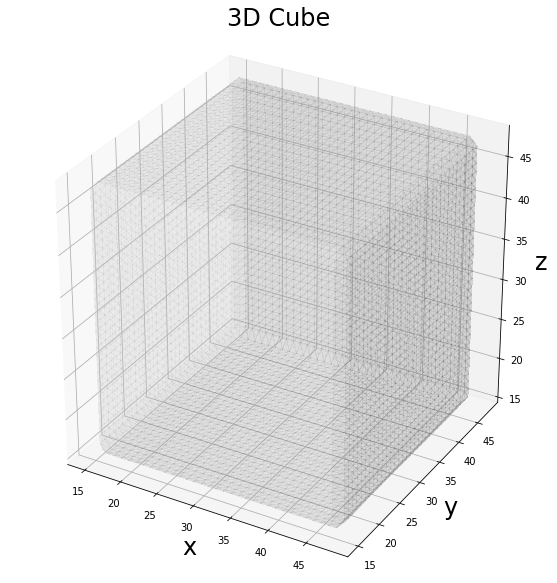

In [9]:
# create a 3D cube as volume mask
volume = cube(shape=(64, 64, 64), side=32)
sitk_volume = sitk.GetImageFromArray(np.uint8(volume))

# get the 3D skeleton of the object
skeletonizer.Execute(sitk_volume)
skeleton = skeletonizer.GetSkeletonImage()

# execute the filter
extractor.Execute(skeleton)

# get the returning values
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()
edgeLUT = extractor.GetEdgeLUTIndexes()
edges_lbl = extractor.GetEdgeMap()

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(volume, 0)

# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
sz, sy, sx = np.where(sitk.GetArrayViewFromImage(skeleton))
if len(sx):
    ax.scatter(sx, sy, sz, color='r')
else:
    print('No skeleton found')
    
# plot the nodes as blue dots
if len(nodes):
    ax.scatter(*zip(*nodes), color='b', marker='o', s=50)
else:
    print('No nodes found in the Graph')
    
# plot the edges as lines between vertices
for ex, ey in edges:
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=2)
    
# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.1,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Cube', fontsize=24)

As for the case of the sphere, neither the 3D cube has a skeleton backbone according to the definition of the Lee algorithm.
Therefore, we cannot define any internal graph.

### Hollow Sphere

No nodes found in the Graph


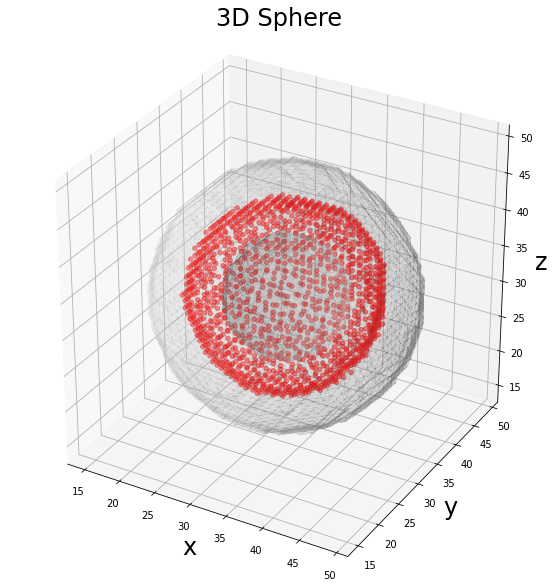

In [10]:
# create a 3D hollow sphere as volume mask
external = sphere(shape=(64, 64, 64), radius=16, position=(32, 32, 32))
hollow = sphere(shape=(64, 64, 64), radius=8, position=(32, 32, 32))
volume = external ^ hollow
sitk_volume = sitk.GetImageFromArray(np.uint8(volume))

# get the 3D skeleton of the object
skeletonizer.Execute(sitk_volume)
skeleton = skeletonizer.GetSkeletonImage()

# execute the filter
extractor.Execute(skeleton)

# get the returning values
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()
edgeLUT = extractor.GetEdgeLUTIndexes()
edges_lbl = extractor.GetEdgeMap()

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(volume, 0)

# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
sz, sy, sx = np.where(sitk.GetArrayViewFromImage(skeleton))
if len(sx):
    ax.scatter(sx, sy, sz, color='r', marker='o', s=20, alpha=0.5)
else:
    print('No skeleton found')
    
if len(nodes):
    # plot the nodes as blue dots
    ax.scatter(*zip(*nodes), color='b', marker='o', s=50)
else:
    print('No nodes found in the Graph')

# plot the edges as lines between vertices
for ex, ey in edges:
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=2)

# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.1,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Sphere', fontsize=24)

The case of the Hollow Sphere is a "particular" case, since the definition of the skeleton in relation to concavities is not trivial.
We commonly think about the skeleton as a line/axis while in 3D geometry its definition could be extended also to surfaces.
This is the case of the hollow sphere, in which the concavity leads to a skeleton given by a sphere itself.
In this case we cannot define a graph, expecially because we have built our graph-extractor setting the `remove_surface` parameter as `True`.

Analogous results can be obtained considering an Hollow Cylinder or an Hollow Cube.
For sake of brevity we have analyzed only the Hollow Sphere as case study.

### Random Blob

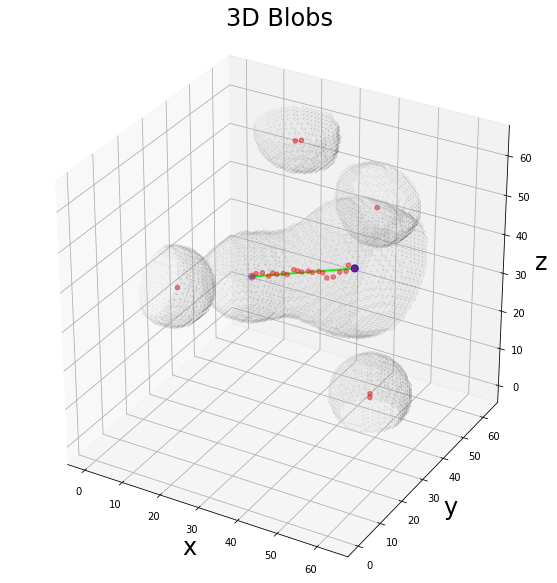

In [11]:
from skimage.data import binary_blobs

# Generate 3D random blobs
volume = binary_blobs(length=64, 
                      blob_size_fraction=.5, 
                      volume_fraction=.1, 
                      seed=42,
                      n_dim=3
                     )
sitk_volume = sitk.GetImageFromArray(np.uint8(volume))

# get the 3D skeleton of the object
skeletonizer.Execute(sitk_volume)
skeleton = skeletonizer.GetSkeletonImage()

# execute the filter
extractor.Execute(skeleton)

# get the returning values
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()
edgeLUT = extractor.GetEdgeLUTIndexes()
edges_lbl = extractor.GetEdgeMap()

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(volume, 0)

# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
sz, sy, sx = np.where(sitk.GetArrayViewFromImage(skeleton))
ax.scatter(sx, sy, sz, color='r', marker='o', s=20, alpha=0.5)

# plot the nodes as blue dots
ax.scatter(*zip(*nodes), color='b', marker='o', s=50)

# plot the edges as lines between vertices
for ex, ey in edges:
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=2)
    
# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.05,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Blobs', fontsize=24)

This is the most general case, in which random 3D shapes can occur.
In this case the graph extractor will return a subgraph for each connected component found in the 3D volume, according to a 8-connectivity.
Since not all the 3D shapes allow the definition of a graph (in this case), the number of the graph connected components is reduced to the only available ones.